.<center> 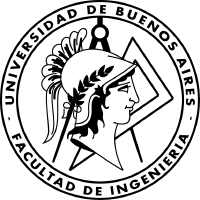



**Universidad de Buenos Aires**

**Facultad de Ingeniería**

**2do Cuatrimestre de 2025**

**Taller de Procesamiento de Señales**

---

**TP6: PCA**

**Alumno:** Lo Coco, Manuel - mlococo@fi.uba.ar - 103938 </center>

---


Se desea incursionar en la temática de clasificación de género musical.

## (a) Preprocesamiento de datos

### (a.1)


Se cargan 3 conjuntos de datos con la función *load* de la librería *Librosa* para cada uno de los audios. Estos tipos de conjuntos se extraen como:

* Entrenamiento: los primeros 5 segundos
* Validación: del segundo 30 al 35
* Testo: del segundo 60 al 90

A su vez, se grafica la respuesta temporal de los primeros 5 segundos de cada uno de los audios.

--2025-10-15 19:30:13--  https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/exclusive.mp3
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/exclusive.mp3 [following]
--2025-10-15 19:30:13--  https://raw.githubusercontent.com/mvera1412/TA136-TB056-TB057-8625/refs/heads/main/data/exclusive.mp3
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2982361 (2.8M) [audio/mpeg]
Saving to: ‘exclusive.mp3’

exclusive.mp3       100%[===================>]   2.84M  --.-KB/s    in 0.01s   

2025-10-15 19:30:13 (196 MB/s) - ‘exclusive.mp

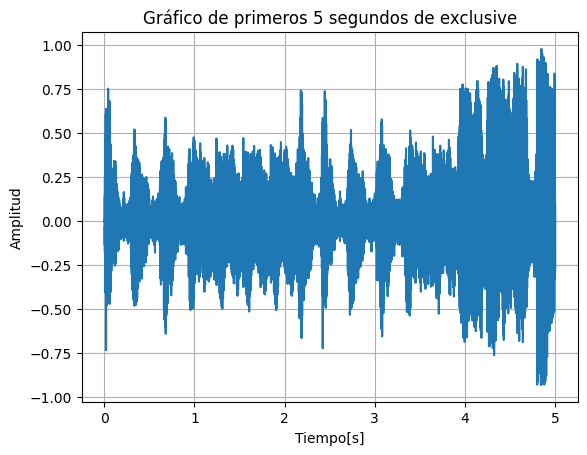

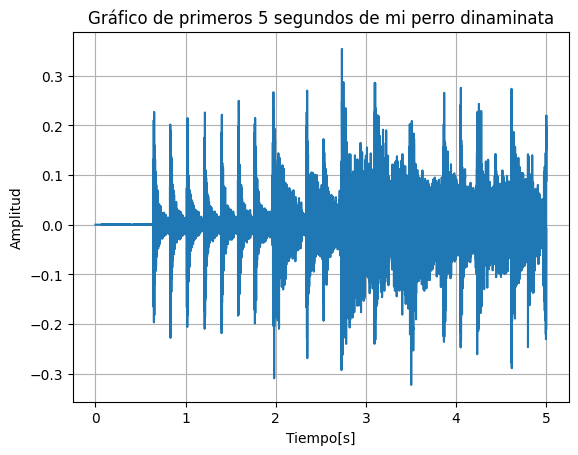

In [ ]:
import librosa
import matplotlib.pyplot as plt
import numpy as np

!wget https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/exclusive.mp3 -O exclusive.mp3
!wget https://github.com/mvera1412/TA136-TB056-TB057-8625/raw/refs/heads/main/data/mi_perro_dinamita.mp3 -O mi_perro_dinamita.mp3


audio_train_exc, sr_exc = librosa.load("exclusive.mp3", sr=None, duration=5)
audio_train_per, sr_per = librosa.load("mi_perro_dinamita.mp3", sr=None, duration=5)

audio_validation_exc, sr_exc = librosa.load("exclusive.mp3", sr=None, offset=30, duration=5)
audio_validation_per, sr_per = librosa.load("mi_perro_dinamita.mp3", sr=None, offset=30, duration=5)

audio_test_exc, sr_exc = librosa.load("exclusive.mp3", sr=None, offset=60, duration=30)
audio_test_per, sr_per = librosa.load("mi_perro_dinamita.mp3", sr=None, offset=60, duration=30)

t_exc = np.linspace(0, len(audio_train_exc)/sr_exc, len(audio_train_exc))
t_per = np.linspace(0, len(audio_train_per)/sr_per, len(audio_train_per))

plt.plot(t_exc, audio_train_exc)
plt.title('Gráfico de primeros 5 segundos de exclusive')
plt.xlabel('Tiempo[s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

plt.plot(t_per, audio_train_per)
plt.title('Gráfico de primeros 5 segundos de mi perro dinaminata')
plt.xlabel('Tiempo[s]')
plt.ylabel('Amplitud')
plt.grid(True)
plt.show()

### (a.2)

Se reproducen los audios de entrenamiento con la función *Audio* de la librería *IPython*.

In [ ]:
from IPython.display import Audio

display(Audio(audio_train_exc, rate=sr_exc))
display(Audio(audio_train_per, rate=sr_per))

### (a.3)


Se grafican los espectogramas de ambas señales con la función *stft* de la librería *Librosa*. STFT representa una señal en el dominio tiempo-frecuencia al realizar la transformada de Fourier discreta (DFT) sobre pequeñas ventanas solapadas.

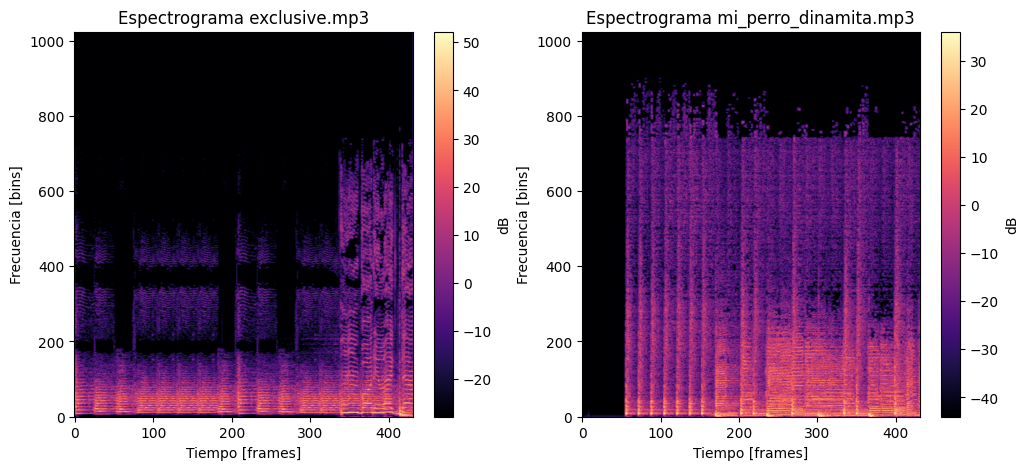

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n_fft = 2048

tf_exc = librosa.stft(audio_train_exc, n_fft=n_fft)
tf_per = librosa.stft(audio_train_per, n_fft=n_fft)

tf_exc_db = librosa.amplitude_to_db(np.abs(tf_exc))
tf_per_db = librosa.amplitude_to_db(np.abs(tf_per))

plt.figure(figsize=(12, 5))

# Espectograma exclusive
plt.subplot(1, 2, 1)
plt.imshow(tf_exc_db, aspect='auto', origin='lower', cmap='magma')
plt.title('Espectrograma exclusive.mp3')
plt.xlabel('Tiempo [frames]')
plt.ylabel('Frecuencia [bins]')
plt.colorbar(label='dB')

# Espectograma mi perro dinamita
plt.subplot(1, 2, 2)
plt.imshow(tf_per_db, aspect='auto', origin='lower', cmap='magma')
plt.title('Espectrograma mi_perro_dinamita.mp3')
plt.xlabel('Tiempo [frames]')
plt.ylabel('Frecuencia [bins]')
plt.colorbar(label='dB')

plt.show()

### (a.4)

Se construye una base de datos de entrenamiento con el espectograma de los primeros 5 segundos de cada canción. A cada frame se le asigna una etiqueta que corresponde con la canción de la que proviene. Se utiliza una fft de 2048 punto, un solapamiento del 75%, se descarta la parte simétrica del espectro y se utiliza una ventana de hann de la misma cantidad de puntos de la fft.

In [ ]:
n_fft = 2048
overlapping = 0.75
hop_length = int(n_fft *(1-overlapping))

X_train = []
y_train = []

for audio, label in [(audio_train_exc, 0), (audio_train_per, 1)]:
    stft = librosa.stft(audio, n_fft=n_fft, window='hann', hop_length=hop_length)
    stft = np.abs(stft[:n_fft//2, :])
    X_train.append(stft.T)
    y_train.append(np.full(stft.shape[1], label))

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = np.vstack(X_train)
y_train = np.concatenate(y_train)

### (a.5)

Se construye una base de datos de validación con 5 segundos de ambas canciones que van del segundo 30 al segundo 35. Para la fft se utilizan los mismos parámetros que se usan en el conjunto de entranamiento.

In [ ]:
X_validation = []
y_validation = []

for audio, label in [(audio_validation_exc, 0), (audio_validation_per, 1)]:
    stft = librosa.stft(audio, n_fft=n_fft, window='hann', hop_length=hop_length)
    stft = np.abs(stft[:n_fft//2, :])
    X_validation.append(stft.T)
    y_validation.append(np.full(stft.shape[1], label))

X_validation = np.array(X_validation)
y_validation = np.array(y_validation)

X_validation = np.vstack(X_validation)
y_validation = np.concatenate(y_validation)

### (a.6)

Se construye una base de datos de testeo con 30 segundos de ambas canciones que van desde el minuto. Para la fft se utilizan los mismos parámetros que se usan en el conjunto de entranamiento.

In [ ]:
X_test = []
y_test = []

for audio, label in [(audio_test_exc, 0), (audio_test_per, 1)]:
    stft = librosa.stft(audio, n_fft=n_fft, window='hann', hop_length=hop_length)
    stft = np.abs(stft[:n_fft//2, :])
    X_test.append(stft.T)
    y_test.append(np.full(stft.shape[1], label))

X_test = np.array(X_test)
y_test = np.array(y_test)

X_test = np.vstack(X_test)
y_test = np.concatenate(y_test)

## (b) Aprendizaje Supervisado

### (b.1)

Para Regresión Logística se usó la función *LogisticRegression* de la librería *sklearn*. Se probaron distintos solvers y se comprobó que la mejor accuracy se logra con el solver default ("lbfgs"). Este solver realiza una regularización L2.

El resultado logrado no es muy preciso, lo que puede deberse a la naturaleza de los datos o a que la separación entre clases no es linealmente separable.

In [ ]:
from sklearn.linear_model import LogisticRegression

clf_LR = LogisticRegression(max_iter = 500)
clf_LR.fit(X_train, y_train)

#accuracy de testeo
acc_LR = clf_LR.score(X_test, y_test)
print(f"Accuracy regresión logística: {acc_LR}")

Accuracy regresión logística: 0.6611842105263158


### (b.2)

Dentro de los modelos generativos, el más simple es el de mezcla de gaussianas, en el cual se asume que los datos de cada clase provienen de una distribución normal multivariada. En este enfoque, el discriminante se obtiene a partir de la probabilidad a posteriori de cada clase y define las fronteras de decisión que separan las regiones del espacio de características.

En particular, los métodos LDA y QDA son dos variantes que modelan dichas mezclas de gaussianas bajo diferentes supuestos:

* LDA asume que todas las clases comparten la misma matriz de covarianza, lo que genera fronteras de decisión lineales.

* QDA  permite que cada clase tenga su propia matriz de covarianza, lo que resulta en fronteras cuadráticas.



In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf_LDA = LinearDiscriminantAnalysis()
clf_LDA.fit(X_train, y_train)

acc_LDA = clf_LDA.score(X_test, y_test)
print(f"Accuracy LDA: {acc_LDA}")

Accuracy LDA: 0.5714009287925697


In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

clf_QDA = QuadraticDiscriminantAnalysis()
clf_QDA.fit(X_train, y_train)

acc_QDA = clf_QDA.score(X_test, y_test)
print(f"Accuracy QDA: {acc_QDA}")


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


Accuracy QDA: 0.5557275541795665


### (b.3)

El algoritmo K-Nearest Neighbors (KNN) es un método supervisado de clasificación que se basa en la proximidad entre las muestras. La idea central es que la clase de un nuevo dato se determina observando a qué clases pertenecen sus k vecinos más cercanos en el conjunto de entrenamiento.

En la etapa de entrenamiento el modelo no construye una función explícita, sino que simplemente almacena los datos de entrada y sus etiquetas. Para clasificar un nuevo punto, se calcula la distancia euclídea con cada muestra de entrenamiento y se seleccionan los k vecinos más próximos.


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Calculo la mejor cantidad de vecinos con los datos de validación
best_n = 0
best_acc_validation = 0
for k in range(1, 20):
    clf_KNN = KNeighborsClassifier(n_neighbors=k)
    clf_KNN.fit(X_train, y_train)
    acc_validation = clf_KNN.score(X_validation, y_validation)
    if acc_validation > best_acc_validation:
        best_n = k
        best_acc_validation = acc_validation

clf_KNN = KNeighborsClassifier(n_neighbors=best_n)
clf_KNN.fit(X_train, y_train)
acc_KNN = clf_KNN.score(X_test, y_test)

print(f"Accuracy KNN con {best_n} vecinos: {acc_KNN}")

Accuracy KNN con 2 vecinos: 0.7428405572755418


### (b.4)

Para SVM se utilizó la función *SVC* de *sklearn*. Se usaron los conjuntos de datos de validación para determinar con que valores de $C$ y $\gamma$ se logra una mejor performance.

In [ ]:
from sklearn.svm import SVC

C_values = [0.001, 0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]

best_acc_validation = 0

for C in C_values:
    for gamma in gamma_values:
        clf_SVM = SVC(kernel='rbf', C=C, gamma=gamma)
        clf_SVM.fit(X_train, y_train)
        acc_validation = clf_SVM.score(X_validation, y_validation)

        if acc_validation > best_acc_validation:
            best_acc_validation = acc_validation
            best_C = C
            best_gamma = gamma

clf_SVM = SVC(kernel='rbf', C=best_C, gamma=best_gamma)
clf_SVM.fit(X_train, y_train)

acc_SVM = clf_SVM.score(X_test, y_test)
print(f"Accuracy SVM con C={best_C} y gamma={best_gamma}: {acc_SVM}")

Accuracy SVM con C=1 y gamma=0.001: 0.7952786377708978


### (b.5)

Para el clasificador basado en árboles de decisión, se compararon distintos criterios de impureza en la división de los nodos. Se observó que el accuracy mejora al utilizar la entropía como función de impureza, en lugar del criterio de Gini.

La entropía mide la cantidad de información o incertidumbre de una partición, buscando generar divisiones que maximicen la ganancia de información. Esto puede producir árboles más profundos y con una mejor capacidad de separación cuando las clases presentan distribuciones más complejas.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

clf_DT = DecisionTreeClassifier(criterion='entropy')
clf_DT.fit(X_train, y_train)

acc_DT = clf_DT.score(X_validation, y_validation)
print(f"La accuracy de árboles de decisión es: {acc_DT}")

La accuracy de árboles de decisión es: 0.8352668213457076


## (c) Aprendizaje No Supervisado

### (c.1)

Para reducir la dimensionalidad de los datos se aplicó la función *PCA*(Principal Component Analysis) de la librería *sklearn*. Esta técnica transforma las variables originales en un nuevo conjunto de componentes principales no correlacionados, ordenados según la varianza que explican en los datos.

Se conservaron las 30 componentes principales, que concentran la mayor parte de la información relevante, permitiendo simplificar el modelo y reducir el ruido sin perder características significativas para la clasificación.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=30)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
X_validation_pca = pca.transform(X_validation)

### (c.2)

Utilizando todos los clasificadores entrenados previamente, se vuelven a entrenar los modelos con el conjunto reducido obtenido tras aplicar PCA. Posteriormente, se calcula el accuracy de cada clasificador para evaluar si la reducción de dimensionalidad mejoró o perjudicó el desempeño del modelo.

Este procedimiento permite analizar si la información retenida por las 30 componentes principales es suficiente para mantener la capacidad de discriminación entre clases, o si, por el contrario, la proyección en un espacio de menor dimensión provoca una pérdida de precisión.

In [ ]:
# Regresión logística
clf_LR.fit(X_train_pca, y_train)
acc_LR_pca = clf_LR.score(X_test_pca, y_test)
print(f"Accuracy regresión logística: {acc_LR}")
print(f"Accuracy regresión logística con PCA: {acc_LR_pca}\n")

# LDA
clf_LDA.fit(X_train_pca, y_train)
acc_LDA_pca = clf_LDA.score(X_test_pca, y_test)
print(f"Accuracy LDA: {acc_LDA}")
print(f"Accuracy LDA con PCA: {acc_LDA_pca}\n")

# QDA
clf_QDA.fit(X_train_pca, y_train)
acc_QDA_pca = clf_QDA.score(X_test_pca, y_test)
print(f"Accuracy QDA: {acc_QDA}")
print(f"Accuracy QDA con PCA: {acc_QDA_pca}\n")

# KNN
clf_KNN.fit(X_train_pca, y_train)
acc_KNN_pca = clf_KNN.score(X_test_pca, y_test)
print(f"Accuracy KNN: {acc_KNN}")
print(f"Accuracy KNN con PCA: {acc_KNN_pca}\n")

# SVM
clf_SVM.fit(X_train_pca, y_train)
acc_SVM_pca = clf_SVM.score(X_test_pca, y_test)
print(f"Accuracy SVM: {acc_SVM}")
print(f"Accuracy SVM con PCA: {acc_SVM_pca}\n")

# Árboles de decisión
clf_DT.fit(X_train_pca, y_train)
acc_DT_pca = clf_DT.score(X_test_pca, y_test)
print(f"Accuracy árboles de decisión: {acc_DT}")
print(f"Accuracy árboles de decisión con PCA: {acc_DT_pca}")

Accuracy regresión logística: 0.6611842105263158
Accuracy regresión logística con PCA: 0.6294504643962848

Accuracy LDA: 0.5714009287925697
Accuracy LDA con PCA: 0.6635061919504643

Accuracy QDA: 0.5557275541795665
Accuracy QDA con PCA: 0.6000386996904025

Accuracy KNN: 0.7428405572755418
Accuracy KNN con PCA: 0.7561919504643962

Accuracy SVM: 0.7952786377708978
Accuracy SVM con PCA: 0.9405959752321982

Accuracy árboles de decisión: 0.8352668213457076
Accuracy árboles de decisión con PCA: 0.9295665634674922


En la mayoría de los clasificadores, el PCA produjo una mejora significativa en la precisión, lo que indica que la reducción de dimensionalidad ayudó a eliminar ruido y redundancia en las variables originales, facilitando la separación entre clases.

En particular, los modelos SVM y árboles de decisión fueron los que experimentaron el mayor incremento de precisión. En estos casos, el PCA facilitó la separación entre clases y redujo el sobreajuste, mejorando la robustez del modelo.

Los métodos lineales (LDA y QDA) también mostraron mejoras, aunque más moderadas, ya que dependen de supuestos sobre la estructura de covarianza que pueden seguir siendo limitantes incluso en el espacio reducido. Por su parte, KNN presentó una mejora leve, coherente con su sensibilidad a la dimensionalidad: menos dimensiones implican distancias más representativas entre muestras.

Regresión logística, en cambio, tuvo un ligero deterioro en el rendimiento, lo cual puede explicarse porque el PCA no siempre preserva las relaciones lineales originales entre las variables y las etiquetas de clase.